# Ensemble Feature Combination Analysis

This notebook analyzes the performance of different feature combinations for EEG classification using ensemble methods. It loads prediction results, computes various metrics (accuracy, balanced accuracy, F1, AUC, AUPRC, etc.), and visualizes the best combinations based on these metrics.

In [ ]:
# Imports and Setup
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
# Ensure the workspace root is on sys.path so local packages (like `utils`) are importable
cwd = Path.cwd()
project_root = None
for parent in [cwd] + list(cwd.parents):
    if (parent / 'utils').is_dir() or (parent / '.git').exists():
        project_root = str(parent)
        break
if project_root is None:
    project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.plotting import analyze_ensemble_performance, set_plot_style

# Available data paths
available_paths = ['/space/gzanardini/emc/emc_ensemble_hv_nonresponders/']

# EMC good ones
#                   ['/space/gzanardini/emc/emc_ensemble_background/',
#                    '/space/gzanardini/emc/emc_ensemble_retrain/',
#                    '/space/gzanardini/emc/emc_ensemble_hv_all/',
#                    '/space/gzanardini/emc/emc_ensemble_hv_responders/',
#                    '/space/gzanardini/emc/emc_ensemble_hv_nonresponders/',
#                    '/space/gzanardini/emc/emc_ips+bg/']

# TUH good ones
#                   ['/space/gzanardini/tuh/tuh_background/', 
#                    '/space/gzanardini/tuh/tuh_background_noieds/',
#                    '/space/gzanardini/tuh/tuh_ensemble_retrain/',
#                    '/space/gzanardini/tuh/tuh_ensemble_retrain_noieds/']

print("Available data paths:")
for i, path in enumerate(available_paths):
    print(f"{i+1}. {path}")

length_to_save = 5
filename_for_saving = 'emc_ens_hv-nr'
savedir = './paperdata/'

Available data paths:
1. /space/gzanardini/emc/emc_ensemble_hv_nonresponders/


In [4]:
colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)

In [5]:
# Shared plotting style/colors
set_plot_style('ggplot')
colors = list(plt.cm.tab10.colors) * (10 // len(plt.cm.tab10.colors) + 1)

In [6]:
# Analysis helpers are now centralized in utils.plotting.analyze_ensemble_performance

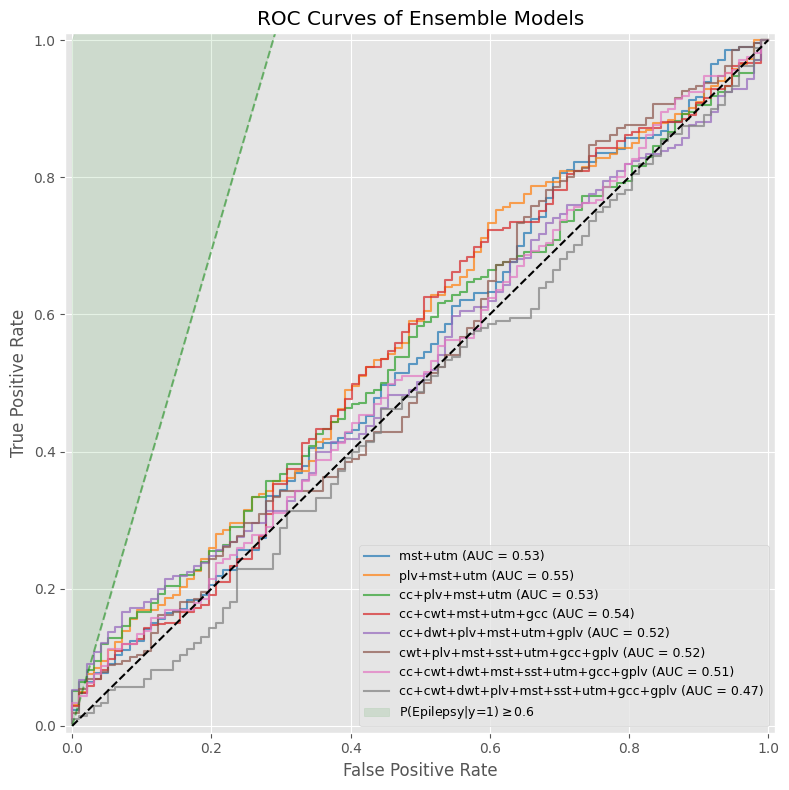


RESULTS FOR: emc_ensemble_hv_nonresponders


In [7]:
for path in available_paths:
    if os.path.exists(path):
        df_summary, df_best, std_df = analyze_ensemble_performance(
            path,
            save_plots=True,
            plot_prefix=os.path.basename(path.rstrip('/')),
            length_to_save=length_to_save,
            filename_for_saving=filename_for_saving,
            save_dir=savedir,
            colors=colors,
        )
        if df_summary is not None:
            print(f"\n{'='*80}")
            print(f"RESULTS FOR: {os.path.basename(path.rstrip('/'))}")
            print(f"{'='*80}")
    else:
        print(f"Path does not exist: {path}")